# Tarefas 4a, 4c e 4d — Clusterização  + Associação + Outlier 
**Responsável:** João

## Tarefa 4a — Clusterização (1 ponto)
Identificar grupos de casas com características semelhantes:
- Aplicar K-Means ao dataset (após PCA ou nas features principais)
- Usar o método Elbow para definir o número ideal de clusters
- Visualizar os clusters em 2D
- Interpretar o perfil de cada cluster (casas baratas, médias, caras)

## Tarefa 4c e 4d — Associação + Outlier (1 ponto)
**Análise de Associação:**
- Discretizar variáveis contínuas em categorias
- Aplicar o algoritmo Apriori para encontrar regras de associação
- Interpretar as regras encontradas
- Avaliar com métricas de suporte, confiança e lift

**Detecção de Outliers:**
- Aplicar o algoritmo Local Outlier Factor (LOF)
- Identificar as casas consideradas outliers
- Visualizar os outliers no dataset
- Interpretar por que essas casas são atípicas

## 1. Imports e Conexão com a API

In [1]:
import Connection as conn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Conexão com a API
my_conn = conn.get_conn("joao_dev", "server@Database")
df = conn.puxar_df(my_conn)
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado: 1460 linhas x 19 colunas


,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,gr_liv_area,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price,id
0,60,RL,8450,Pave,CollgCr,7,5,2003,2003,1710,2,1,3,1,8,2.0,548.0,208500,1
1,20,RL,9600,Pave,Veenker,6,8,1976,1976,1262,2,0,3,1,6,2.0,460.0,181500,2
2,60,RL,11250,Pave,CollgCr,7,5,2001,2002,1786,2,1,3,1,6,2.0,608.0,223500,3
3,70,RL,9550,Pave,Crawfor,7,5,1915,1970,1717,1,0,3,1,7,3.0,642.0,140000,4
4,60,RL,14260,Pave,NoRidge,8,5,2000,2000,2198,2,1,4,1,9,3.0,836.0,250000,5


## 2. Preparação dos Dados para Clusterização
Selecionar as variáveis numéricas, tratar valores faltantes e padronizar os dados com StandardScaler.

In [3]:
# Identificar colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Colunas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColunas categóricas ({len(cat_cols)}): {cat_cols}")

Colunas numéricas (16): ['ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area', 'sale_price', 'id']

Colunas categóricas (3): ['ms_zoning', 'street', 'neighborhood']


C:\Users\Matheus Games\AppData\Local\Temp\ipykernel_10544\2083269926.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [4]:
# Remover colunas que não são features (id, target)
cols_to_remove = ['id', 'sale_price']
feature_cols = [col for col in numeric_cols if col not in cols_to_remove]

print(f"Features selecionadas para clusterização ({len(feature_cols)}):")
print(feature_cols)

# Preparar os dados removendo NaN
X = df[feature_cols].dropna()
# Guardar o sale_price correspondente para análise
y = df.loc[X.index, 'sale_price']
print(f"\nAmostras após remoção de NaN: {X.shape[0]}")

Features selecionadas para clusterização (14):
['ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area']

Amostras após remoção de NaN: 1460


In [5]:
# Padronização com StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar padronização
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("Estatísticas após padronização:")
print(f"  Média (deve ser ~0):  {X_scaled_df.mean().mean():.6f}")
print(f"  Desvio (deve ser ~1): {X_scaled_df.std().mean():.6f}")
X_scaled_df.describe().round(3)

Estatísticas após padronização:
  Média (deve ser ~0):  0.000000
  Desvio (deve ser ~1): 1.000343


,ms_subclass,lot_area,overall_qual,overall_cond,year_built,year_remod_add,gr_liv_area,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.873,-0.924,-3.688,-4.113,-3.288,-1.689,-2.249,-2.842,-0.762,-3.515,-4.751,-2.780,-2.365,-2.213
25%,-0.873,-0.297,-0.795,-0.517,-0.572,-0.866,-0.735,-1.026,-0.762,-1.062,-0.211,-0.934,-1.027,-0.648
50%,-0.163,-0.104,-0.072,-0.517,0.057,0.443,-0.098,0.790,-0.762,0.164,-0.211,-0.319,0.312,0.033
75%,0.310,0.109,0.651,0.382,0.952,0.927,0.497,0.790,1.228,0.164,-0.211,0.297,0.312,0.482
max,3.148,20.518,2.821,3.079,1.283,1.218,7.856,2.606,3.217,6.295,8.869,4.605,2.989,4.422


## 3. Redução de Dimensionalidade com PCA (para visualização)
Antes da clusterização, aplicar PCA para reduzir os dados a 2 dimensões, facilitando a visualização dos clusters.

In [6]:
# PCA para redução a 2 dimensões (visualização)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variância explicada por PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variância explicada por PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Variância total explicada (2 componentes): {sum(pca.explained_variance_ratio_)*100:.2f}%")

Variância explicada por PC1: 33.64%
Variância explicada por PC2: 15.25%
Variância total explicada (2 componentes): 48.89%


---
# TAREFA 4a — Clusterização com K-Means
---

## 4. Método Elbow para Definir o Número Ideal de Clusters
O método Elbow (cotovelo) analisa a inércia (soma das distâncias quadradas dentro de cada cluster) para diferentes valores de K. O ponto de "cotovelo" indica o K ideal.

  K=2: Inércia = 15585.17
  K=3: Inércia = 13760.82
  K=4: Inércia = 12590.57
  K=5: Inércia = 11661.48
  K=6: Inércia = 10784.31
  K=7: Inércia = 9972.72
  K=8: Inércia = 9417.83
  K=9: Inércia = 8861.31
  K=10: Inércia = 8407.45


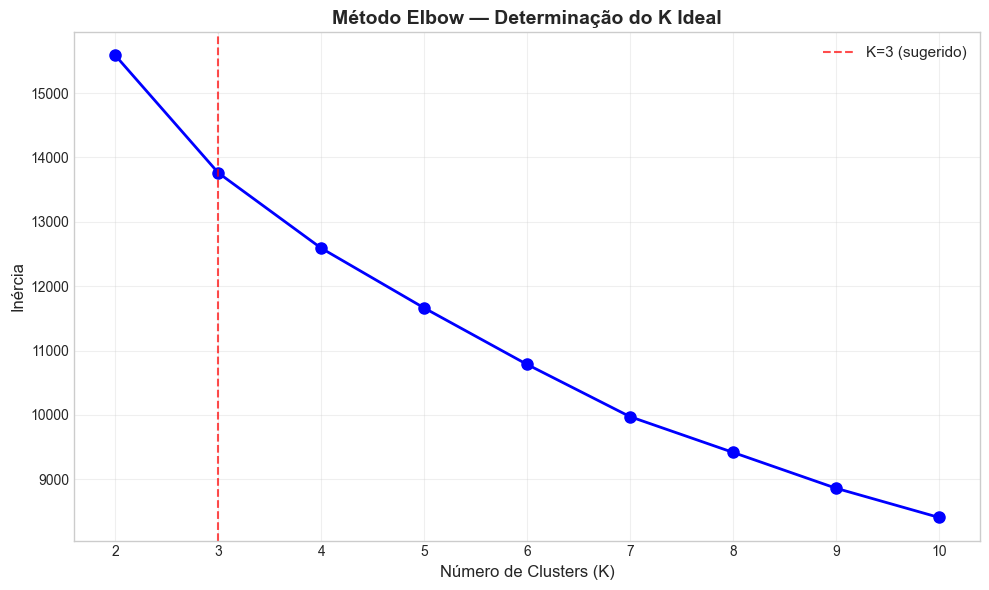

In [7]:
# Método Elbow
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)
    print(f"  K={k}: Inércia = {kmeans_temp.inertia_:.2f}")

# Plotar o gráfico Elbow
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Número de Clusters (K)', fontsize=12)
ax.set_ylabel('Inércia', fontsize=12)
ax.set_title('Método Elbow — Determinação do K Ideal', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_range))

# Destacar o ponto de cotovelo (K=3 como padrão recomendado)
ax.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (sugerido)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Aplicação do K-Means com K=3
Com base no método Elbow, aplicamos K-Means com 3 clusters para segmentar as casas em grupos com características semelhantes.

In [8]:
# Aplicar K-Means com K=3
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Adicionar rótulos de cluster ao DataFrame
df_clusters = X.copy()
df_clusters['cluster'] = clusters
df_clusters['sale_price'] = y.values

print(f"K-Means com {n_clusters} clusters:")
print(f"  Inércia final: {kmeans.inertia_:.2f}")
print(f"\nDistribuição dos clusters:")
print(df_clusters['cluster'].value_counts().sort_index())

K-Means com 3 clusters:
  Inércia final: 13760.82

Distribuição dos clusters:
cluster
0    684
1    709
2     67
Name: count, dtype: int64


## 6. Visualização dos Clusters em 2D
Usando os dados reduzidos com PCA, visualizamos a distribuição dos clusters.

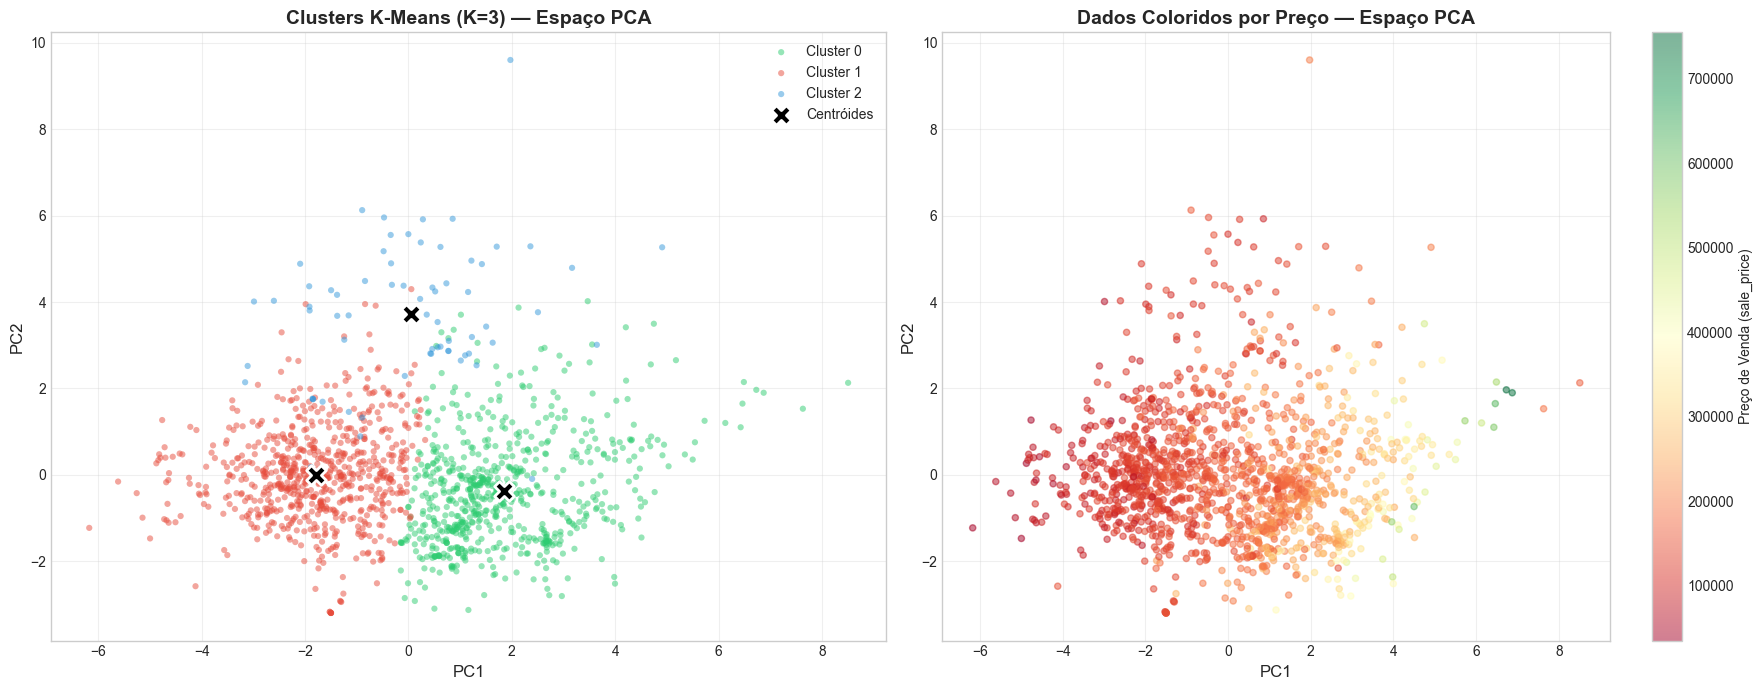

In [9]:
# Visualização dos clusters em 2D (PCA)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Clusters K-Means
colors = ['#2ecc71', '#e74c3c', '#3498db']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(n_clusters):
    mask = clusters == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=colors[i], label=cluster_names[i],
                    alpha=0.5, s=20, edgecolors='none')

# Plotar centróides (transformados para PCA)
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, linewidths=2,
                edgecolors='white', label='Centróides', zorder=5)

axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('Clusters K-Means (K=3) — Espaço PCA', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Clusters coloridos por preço médio
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=y.values, cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[1], label='Preço de Venda (sale_price)')
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('Dados Coloridos por Preço — Espaço PCA', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Interpretação do Perfil de Cada Cluster
Analisar as estatísticas de cada cluster para entender o perfil de casas (baratas, médias, caras).

In [10]:
# Estatísticas por cluster
print("=" * 65)
print("  PERFIL DOS CLUSTERS")
print("=" * 65)

# Variáveis-chave para interpretação
key_vars = ['sale_price', 'overall_qual', 'gr_liv_area', 'garage_area', 'year_built', 'totrms_abvgrd']

cluster_stats = df_clusters.groupby('cluster')[key_vars].agg(['mean', 'median', 'count'])

for c in range(n_clusters):
    print(f"\n--- Cluster {c} ---")
    cluster_data = df_clusters[df_clusters['cluster'] == c]
    print(f"  Quantidade de casas: {len(cluster_data)}")
    print(f"  Preço médio:         ${cluster_data['sale_price'].mean():,.2f}")
    print(f"  Preço mediano:       ${cluster_data['sale_price'].median():,.2f}")
    print(f"  Qualidade média:     {cluster_data['overall_qual'].mean():.2f}")
    print(f"  Área média (sqft):   {cluster_data['gr_liv_area'].mean():.0f}")
    print(f"  Área garagem média:  {cluster_data['garage_area'].mean():.0f}")
    print(f"  Ano construção médio:{cluster_data['year_built'].mean():.0f}")
    print(f"  Cômodos médio:       {cluster_data['totrms_abvgrd'].mean():.1f}")

  PERFIL DOS CLUSTERS

--- Cluster 0 ---
  Quantidade de casas: 684
  Preço médio:         $237,080.31
  Preço mediano:       $215,000.00
  Qualidade média:     7.15
  Área média (sqft):   1831
  Área garagem média:  594
  Ano construção médio:1993
  Cômodos médio:       7.2

--- Cluster 1 ---
  Quantidade de casas: 709
  Preço médio:         $131,523.08
  Preço mediano:       $132,500.00
  Qualidade média:     5.20
  Área média (sqft):   1188
  Área garagem média:  363
  Ano construção médio:1952
  Cômodos médio:       5.7

--- Cluster 2 ---
  Quantidade de casas: 67
  Preço médio:         $130,330.60
  Preço mediano:       $129,900.00
  Qualidade média:     4.91
  Área média (sqft):   1761
  Área garagem média:  400
  Ano construção médio:1947
  Cômodos médio:       8.5


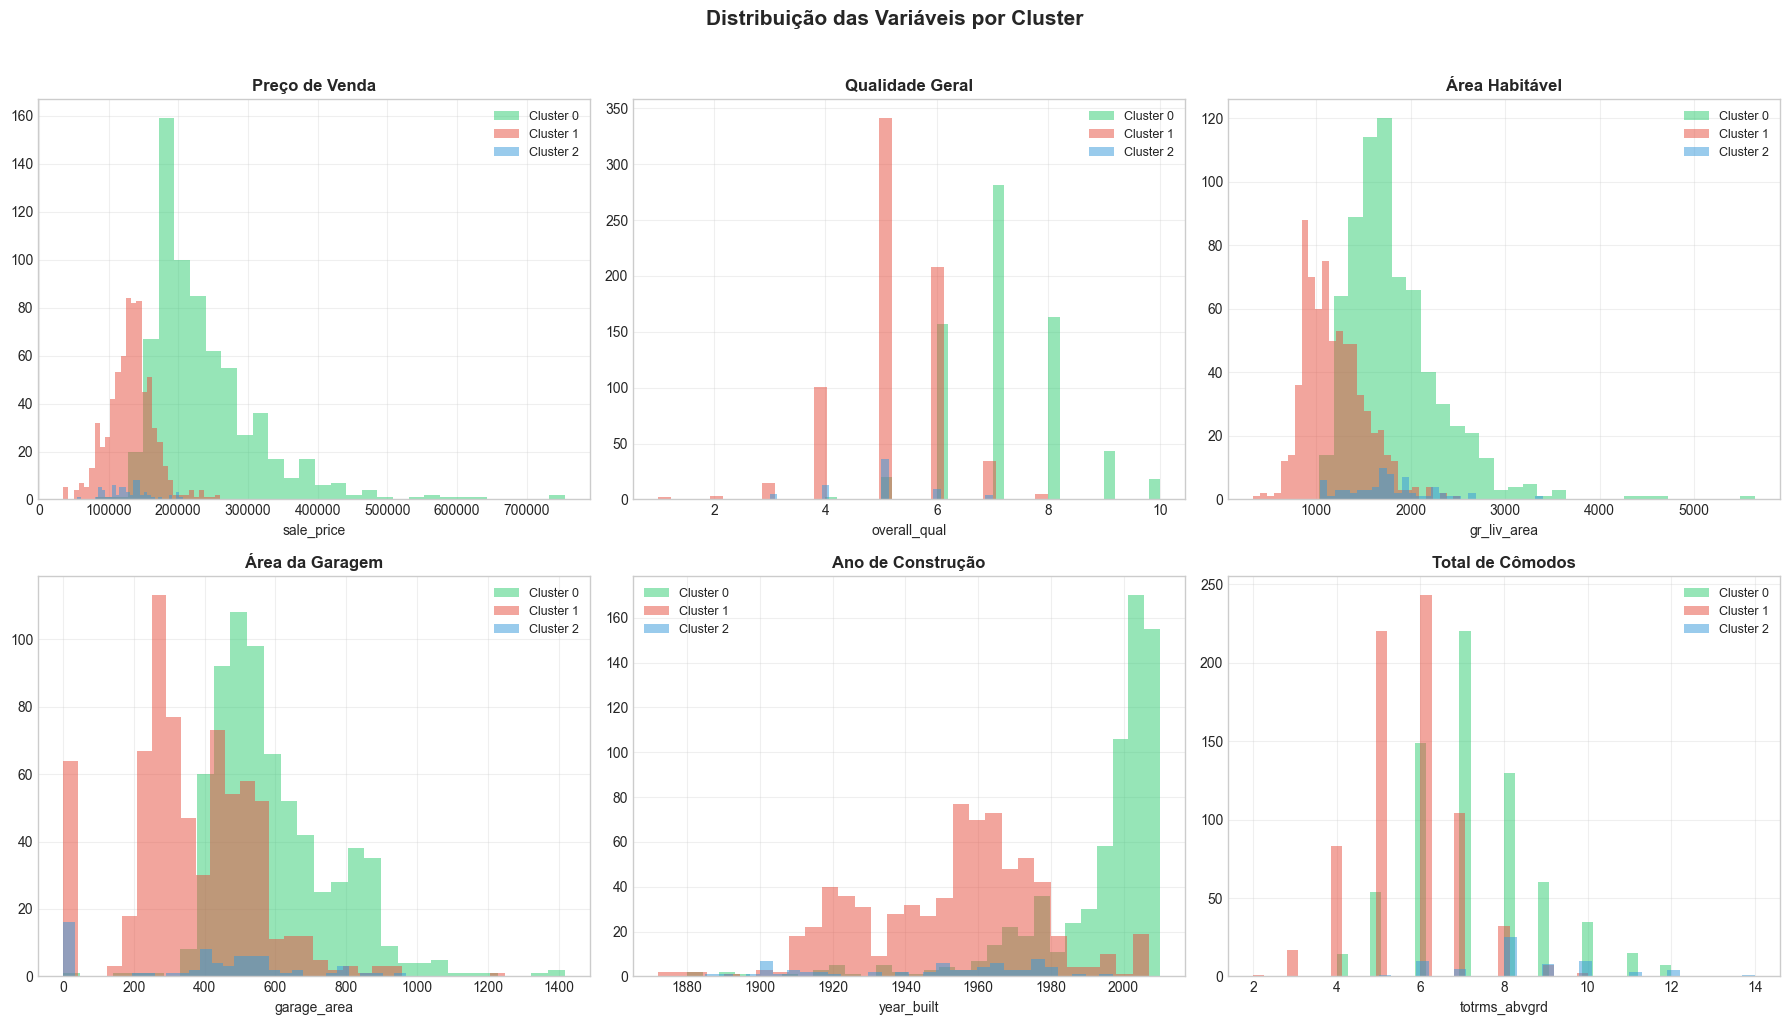

In [11]:
# Visualização comparativa dos clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_vars = ['sale_price', 'overall_qual', 'gr_liv_area', 'garage_area', 'year_built', 'totrms_abvgrd']
plot_titles = ['Preço de Venda', 'Qualidade Geral', 'Área Habitável', 'Área da Garagem', 'Ano de Construção', 'Total de Cômodos']

for idx, (var, title) in enumerate(zip(plot_vars, plot_titles)):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    
    for c in range(n_clusters):
        cluster_data = df_clusters[df_clusters['cluster'] == c][var]
        ax.hist(cluster_data, bins=30, alpha=0.5, label=f'Cluster {c}', color=colors[c])
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribuição das Variáveis por Cluster', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Matheus Games\AppData\Local\Temp\ipykernel_10544\2964913889.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df_clusters[df_clusters['cluster'] == c]['sale_price'] for c in range(n_clusters)],


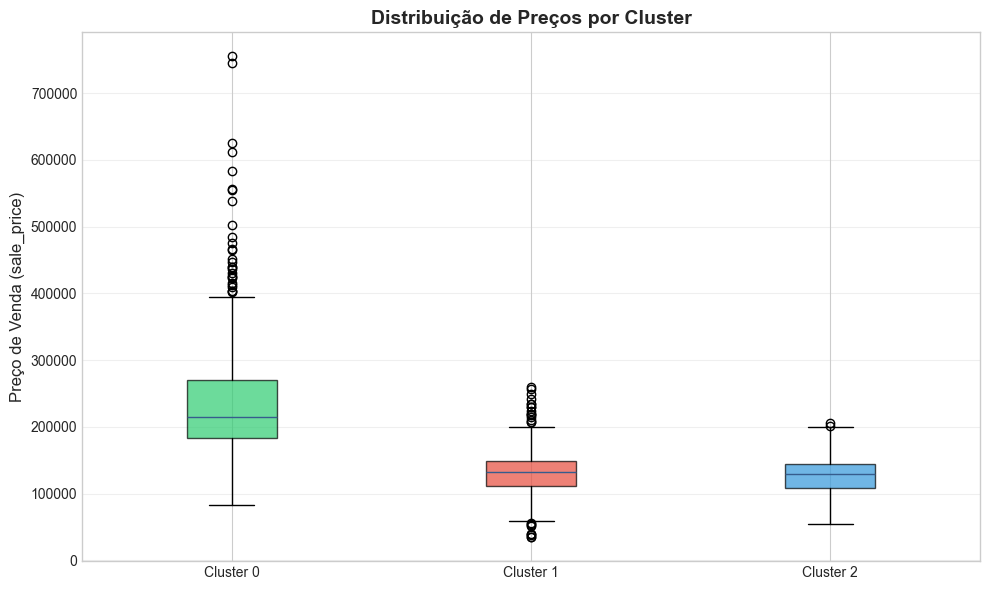

In [12]:
# Boxplot de preços por cluster
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([df_clusters[df_clusters['cluster'] == c]['sale_price'] for c in range(n_clusters)],
                labels=[f'Cluster {c}' for c in range(n_clusters)],
                patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Preço de Venda (sale_price)', fontsize=12)
ax.set_title('Distribuição de Preços por Cluster', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Clusterização via API
Comparar os resultados locais com os resultados retornados pela API.

In [13]:
# Clusterização via API
api_kmeans = conn.get_kmeans(my_conn, n_clusters=3)

print("Resultado da API — K-Means:")
print(f"  Tipo de resposta: {type(api_kmeans)}")

if isinstance(api_kmeans, dict):
    for key, value in api_kmeans.items():
        if isinstance(value, list) and len(value) > 10:
            print(f"  {key}: [{value[0]}, {value[1]}, {value[2]}, ... ] ({len(value)} itens)")
        else:
            print(f"  {key}: {value}")

Resultado da API — K-Means:
  Tipo de resposta: <class 'dict'>
  usuario: joao_dev
  n_clusters: 3
  elbow: {'2': 4624.38, '3': 3713.3, '4': 2886.76, '5': 2561.11, '6': 2311.28, '7': 2129.97}
  perfil_clusters: {'0': {'lot_area': 8845.15, 'overall_qual': 5.42, 'gr_liv_area': 1276.27, 'garage_area': 385.41, 'sale_price': 139692.77}, '1': {'lot_area': 12617.36, 'overall_qual': 7.47, 'gr_liv_area': 1993.73, 'garage_area': 648.81, 'sale_price': 263024.7}, '2': {'lot_area': 163513.5, 'overall_qual': 6.25, 'gr_liv_area': 1947.5, 'garage_area': 542.5, 'sale_price': 295737.5}}
  distribuicao: {'0': 973, '1': 483, '2': 4}


---
# TAREFA 4c — Análise de Associação (Apriori)
---
Discretizar variáveis contínuas em categorias e aplicar o algoritmo Apriori para encontrar regras de associação entre as características das casas.

## 9. Discretização das Variáveis Contínuas
Para aplicar regras de associação, é necessário transformar variáveis contínuas em categorias discretas (ex: qualidade alta/média/baixa, área grande/média/pequena).

In [14]:
# Discretização das variáveis contínuas em categorias
df_disc = pd.DataFrame()

# Qualidade geral: baixa (1-4), média (5-7), alta (8-10)
df_disc['qualidade'] = pd.cut(df['overall_qual'],
                              bins=[0, 4, 7, 10],
                              labels=['baixa', 'media', 'alta'])

# Área habitável: pequena, média, grande
df_disc['area'] = pd.cut(df['gr_liv_area'],
                         bins=[0, 1000, 1500, float('inf')],
                         labels=['pequena', 'media', 'grande'])

# Preço: baixo, médio, alto (baseado em tercis)
price_terciles = df['sale_price'].quantile([0.33, 0.66])
df_disc['preco'] = pd.cut(df['sale_price'],
                          bins=[0, price_terciles.iloc[0], price_terciles.iloc[1], float('inf')],
                          labels=['baixo', 'medio', 'alto'])

# Ano de construção: antigo, médio, novo
df_disc['idade_casa'] = pd.cut(df['year_built'],
                               bins=[0, 1960, 2000, float('inf')],
                               labels=['antiga', 'media', 'nova'])

# Garagem: sem garagem, pequena, grande
df_disc['garagem'] = pd.cut(df['garage_area'].fillna(0),
                            bins=[-1, 0, 400, float('inf')],
                            labels=['sem_garagem', 'pequena', 'grande'])

# Condição geral: ruim (1-4), média (5-7), boa (8-10)
df_disc['condicao'] = pd.cut(df['overall_cond'],
                             bins=[0, 4, 7, 10],
                             labels=['ruim', 'media', 'boa'])

print("Variáveis discretizadas:")
print(df_disc.head(10))
print(f"\nShape: {df_disc.shape}")

Variáveis discretizadas:
  qualidade    area  preco idade_casa  garagem condicao
0     media  grande   alto       nova   grande    media
1     media   media  medio      media   grande      boa
2     media  grande   alto       nova   grande    media
3     media  grande  medio     antiga   grande    media
4      alta  grande   alto      media   grande    media
5     media   media  medio      media   grande    media
6      alta  grande   alto       nova   grande    media
7     media  grande   alto      media   grande    media
8     media  grande  baixo     antiga   grande    media
9     media   media  baixo     antiga  pequena    media

Shape: (1460, 6)


In [15]:
# Criar o DataFrame binário (One-Hot Encoding) para o Apriori
df_onehot = pd.get_dummies(df_disc)
print(f"DataFrame binário para Apriori: {df_onehot.shape[0]} amostras x {df_onehot.shape[1]} features")
print(f"\nColunas: {list(df_onehot.columns)}")
df_onehot.head()

DataFrame binário para Apriori: 1460 amostras x 18 features

Colunas: ['qualidade_baixa', 'qualidade_media', 'qualidade_alta', 'area_pequena', 'area_media', 'area_grande', 'preco_baixo', 'preco_medio', 'preco_alto', 'idade_casa_antiga', 'idade_casa_media', 'idade_casa_nova', 'garagem_sem_garagem', 'garagem_pequena', 'garagem_grande', 'condicao_ruim', 'condicao_media', 'condicao_boa']


,qualidade_baixa,qualidade_media,qualidade_alta,area_pequena,area_media,area_grande,preco_baixo,preco_medio,preco_alto,idade_casa_antiga,idade_casa_media,idade_casa_nova,garagem_sem_garagem,garagem_pequena,garagem_grande,condicao_ruim,condicao_media,condicao_boa
0,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False
1,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True
2,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False
3,False,True,False,False,False,True,False,True,False,True,False,False,False,False,True,False,True,False
4,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,False,True,False


## 10. Aplicação do Algoritmo Apriori
Encontrar itemsets frequentes e gerar regras de associação com métricas de suporte, confiança e lift.

In [16]:
# Importar mlxtend para Apriori
try:
    from mlxtend.frequent_patterns import apriori, association_rules
    print("mlxtend importado com sucesso!")
except ImportError:
    print("Instalando mlxtend...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'mlxtend'])
    from mlxtend.frequent_patterns import apriori, association_rules
    print("mlxtend instalado e importado!")

# Aplicar Apriori com suporte mínimo de 10%
frequent_itemsets = apriori(df_onehot.astype(bool), min_support=0.1, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)

print(f"\nItemsets frequentes encontrados: {len(frequent_itemsets)}")
print(f"\nTop 15 itemsets mais frequentes:")
frequent_itemsets.head(15)

Instalando mlxtend...
mlxtend instalado e importado!

Itemsets frequentes encontrados: 183

Top 15 itemsets mais frequentes:


,support,itemsets
13,0.875342,frozenset({condicao_media})
0,0.746575,frozenset({qualidade_media})
12,0.660959,frozenset({garagem_grande})
25,0.658904,"frozenset({condicao_media, qualidade_media})"
67,0.606849,"frozenset({condicao_media, garagem_grande})"
24,0.476712,"frozenset({qualidade_media, garagem_grande})"
4,0.462329,frozenset({area_grande})
96,0.435616,"frozenset({condicao_media, qualidade_media, ga..."
46,0.416438,"frozenset({area_grande, condicao_media})"
9,0.406849,frozenset({idade_casa_media})


In [17]:
# Gerar regras de associação
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5, num_itemsets=len(frequent_itemsets))
rules = rules.sort_values('lift', ascending=False)

print(f"Regras de associação encontradas: {len(rules)}")
print(f"\nTop 15 regras por lift:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Regras de associação encontradas: 599

Top 15 regras por lift:


,antecedents,consequents,support,confidence,lift
592,"frozenset({preco_alto, idade_casa_nova})","frozenset({condicao_media, qualidade_alta, gar...",0.103425,0.576336,3.913723
591,"frozenset({condicao_media, qualidade_alta, gar...","frozenset({preco_alto, idade_casa_nova})",0.103425,0.702326,3.913723
586,"frozenset({preco_alto, garagem_grande, idade_c...","frozenset({condicao_media, qualidade_alta})",0.103425,0.587549,3.899186
595,"frozenset({condicao_media, qualidade_alta})","frozenset({preco_alto, garagem_grande, idade_c...",0.103425,0.686364,3.899186
575,"frozenset({preco_alto, idade_casa_nova})","frozenset({condicao_media, qualidade_alta})",0.104110,0.580153,3.850104
576,"frozenset({condicao_media, qualidade_alta})","frozenset({preco_alto, idade_casa_nova})",0.104110,0.690909,3.850104
567,"frozenset({qualidade_alta, garagem_grande})","frozenset({preco_alto, idade_casa_nova})",0.104110,0.678571,3.781352
566,"frozenset({preco_alto, idade_casa_nova})","frozenset({qualidade_alta, garagem_grande})",0.104110,0.580153,3.781352
596,"frozenset({qualidade_alta, garagem_grande})","frozenset({preco_alto, condicao_media, idade_c...",0.103425,0.674107,3.770868
584,"frozenset({preco_alto, condicao_media, idade_c...","frozenset({qualidade_alta, garagem_grande})",0.103425,0.578544,3.770868


## 11. Interpretação das Regras de Associação
Analisar as regras mais significativas e entender os padrões encontrados.

In [18]:
# Interpretação das regras
print("=" * 65)
print("  INTERPRETAÇÃO DAS REGRAS DE ASSOCIAÇÃO")
print("=" * 65)

# Filtrar regras com bom lift (> 1.5) e boa confiança (> 0.6)
good_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.6)]
good_rules = good_rules.sort_values('lift', ascending=False)

print(f"\nRegras significativas (lift > 1.5, confiança > 60%): {len(good_rules)}")

for idx, row in good_rules.head(10).iterrows():
    antecedents = ', '.join(list(row['antecedents']))
    consequents = ', '.join(list(row['consequents']))
    print(f"\n  📌 SE {antecedents}")
    print(f"     ENTÃO {consequents}")
    print(f"     Suporte: {row['support']:.3f} | Confiança: {row['confidence']:.3f} | Lift: {row['lift']:.3f}")

  INTERPRETAÇÃO DAS REGRAS DE ASSOCIAÇÃO

Regras significativas (lift > 1.5, confiança > 60%): 214

  📌 SE condicao_media, qualidade_alta, garagem_grande
     ENTÃO preco_alto, idade_casa_nova
     Suporte: 0.103 | Confiança: 0.702 | Lift: 3.914

  📌 SE condicao_media, qualidade_alta
     ENTÃO preco_alto, garagem_grande, idade_casa_nova
     Suporte: 0.103 | Confiança: 0.686 | Lift: 3.899

  📌 SE condicao_media, qualidade_alta
     ENTÃO preco_alto, idade_casa_nova
     Suporte: 0.104 | Confiança: 0.691 | Lift: 3.850

  📌 SE qualidade_alta, garagem_grande
     ENTÃO preco_alto, idade_casa_nova
     Suporte: 0.104 | Confiança: 0.679 | Lift: 3.781

  📌 SE qualidade_alta, garagem_grande
     ENTÃO preco_alto, condicao_media, idade_casa_nova
     Suporte: 0.103 | Confiança: 0.674 | Lift: 3.771

  📌 SE qualidade_alta
     ENTÃO preco_alto, garagem_grande, idade_casa_nova
     Suporte: 0.104 | Confiança: 0.664 | Lift: 3.771

  📌 SE qualidade_alta
     ENTÃO preco_alto, condicao_media, garag

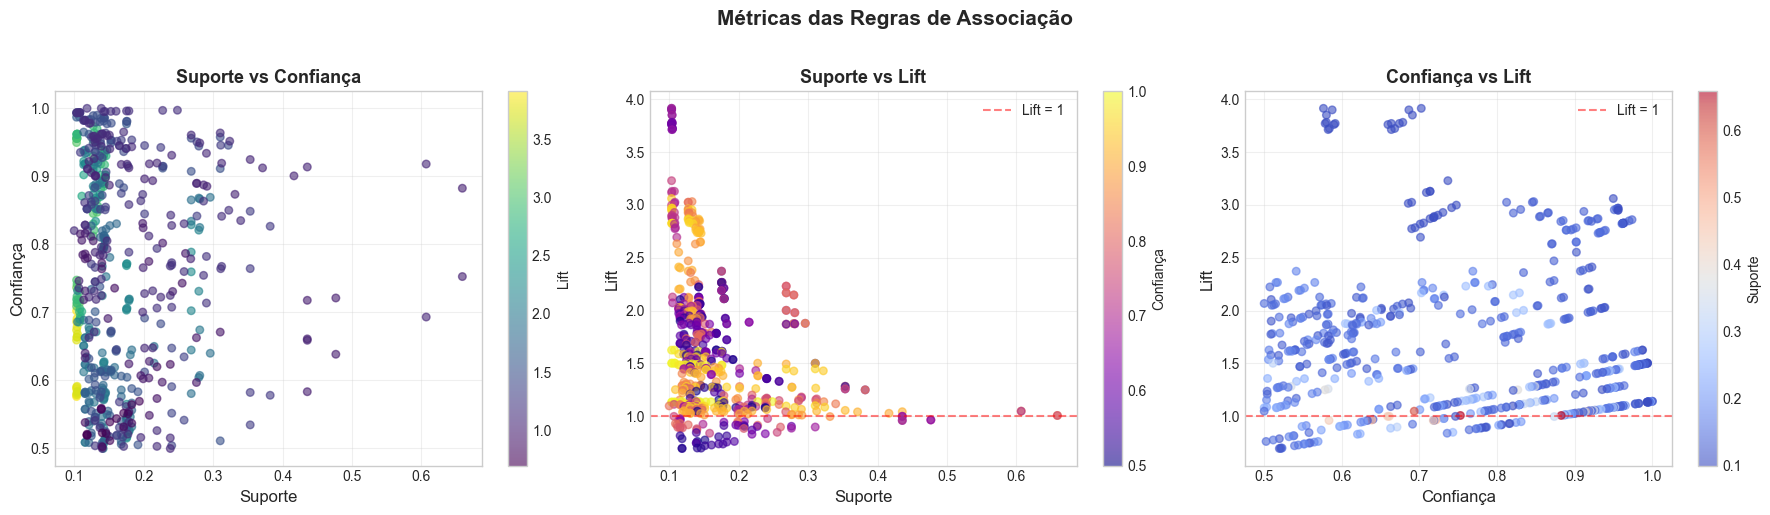

In [19]:
# Visualização das métricas das regras
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Suporte vs Confiança
scatter1 = axes[0].scatter(rules['support'], rules['confidence'],
                           c=rules['lift'], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter1, ax=axes[0], label='Lift')
axes[0].set_xlabel('Suporte', fontsize=12)
axes[0].set_ylabel('Confiança', fontsize=12)
axes[0].set_title('Suporte vs Confiança', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Suporte vs Lift
scatter2 = axes[1].scatter(rules['support'], rules['lift'],
                           c=rules['confidence'], cmap='plasma', alpha=0.6, s=30)
plt.colorbar(scatter2, ax=axes[1], label='Confiança')
axes[1].set_xlabel('Suporte', fontsize=12)
axes[1].set_ylabel('Lift', fontsize=12)
axes[1].set_title('Suporte vs Lift', fontsize=13, fontweight='bold')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Lift = 1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confiança vs Lift
scatter3 = axes[2].scatter(rules['confidence'], rules['lift'],
                           c=rules['support'], cmap='coolwarm', alpha=0.6, s=30)
plt.colorbar(scatter3, ax=axes[2], label='Suporte')
axes[2].set_xlabel('Confiança', fontsize=12)
axes[2].set_ylabel('Lift', fontsize=12)
axes[2].set_title('Confiança vs Lift', fontsize=13, fontweight='bold')
axes[2].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Lift = 1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Métricas das Regras de Associação', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Regras de Associação via API

In [20]:
# Regras de associação via API
api_association = conn.get_association(my_conn, min_support=0.1)

print("Resultado da API — Associação:")
print(f"  Tipo de resposta: {type(api_association)}")

if isinstance(api_association, dict):
    for key, value in api_association.items():
        if isinstance(value, list) and len(value) > 5:
            print(f"  {key}: {len(value)} itens")
            for item in value[:5]:
                print(f"    - {item}")
        else:
            print(f"  {key}: {value}")

Resultado da API — Associação:
  Tipo de resposta: <class 'dict'>
  usuario: joao_dev
  min_support: 0.1
  regras: [{'antecedente': 'qual_alta', 'consequente': 'preco_alto', 'suporte': 0.3753, 'confianca': 0.9179, 'lift': 1.8308}, {'antecedente': 'casa_nova', 'consequente': 'preco_alto', 'suporte': 0.3774, 'confianca': 0.8893, 'lift': 1.7737}, {'antecedente': 'area_grande', 'consequente': 'preco_alto', 'suporte': 0.5007, 'confianca': 0.7907, 'lift': 1.5771}, {'antecedente': 'garage_grande', 'consequente': 'preco_alto', 'suporte': 0.5007, 'confianca': 0.7114, 'lift': 1.4188}]


---
# TAREFA 4d — Detecção de Outliers (LOF)
---
Aplicar o algoritmo Local Outlier Factor (LOF) para identificar casas atípicas no dataset.

## 13. Aplicação do LOF (Local Outlier Factor)
O LOF mede a densidade local de cada ponto em relação aos seus vizinhos. Pontos com densidade significativamente menor são considerados outliers.

In [21]:
# Aplicar LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = lof.negative_outlier_factor_

# -1 = outlier, 1 = normal
n_outliers = (lof_labels == -1).sum()
n_normal = (lof_labels == 1).sum()

print(f"Resultados do LOF (n_neighbors=20, contamination=5%):")
print(f"  Amostras normais: {n_normal} ({n_normal/len(lof_labels)*100:.1f}%)")
print(f"  Outliers detectados: {n_outliers} ({n_outliers/len(lof_labels)*100:.1f}%)")

Resultados do LOF (n_neighbors=20, contamination=5%):
  Amostras normais: 1387 (95.0%)
  Outliers detectados: 73 (5.0%)


## 14. Visualização dos Outliers no Dataset
Visualizar os outliers identificados pelo LOF no espaço reduzido por PCA.

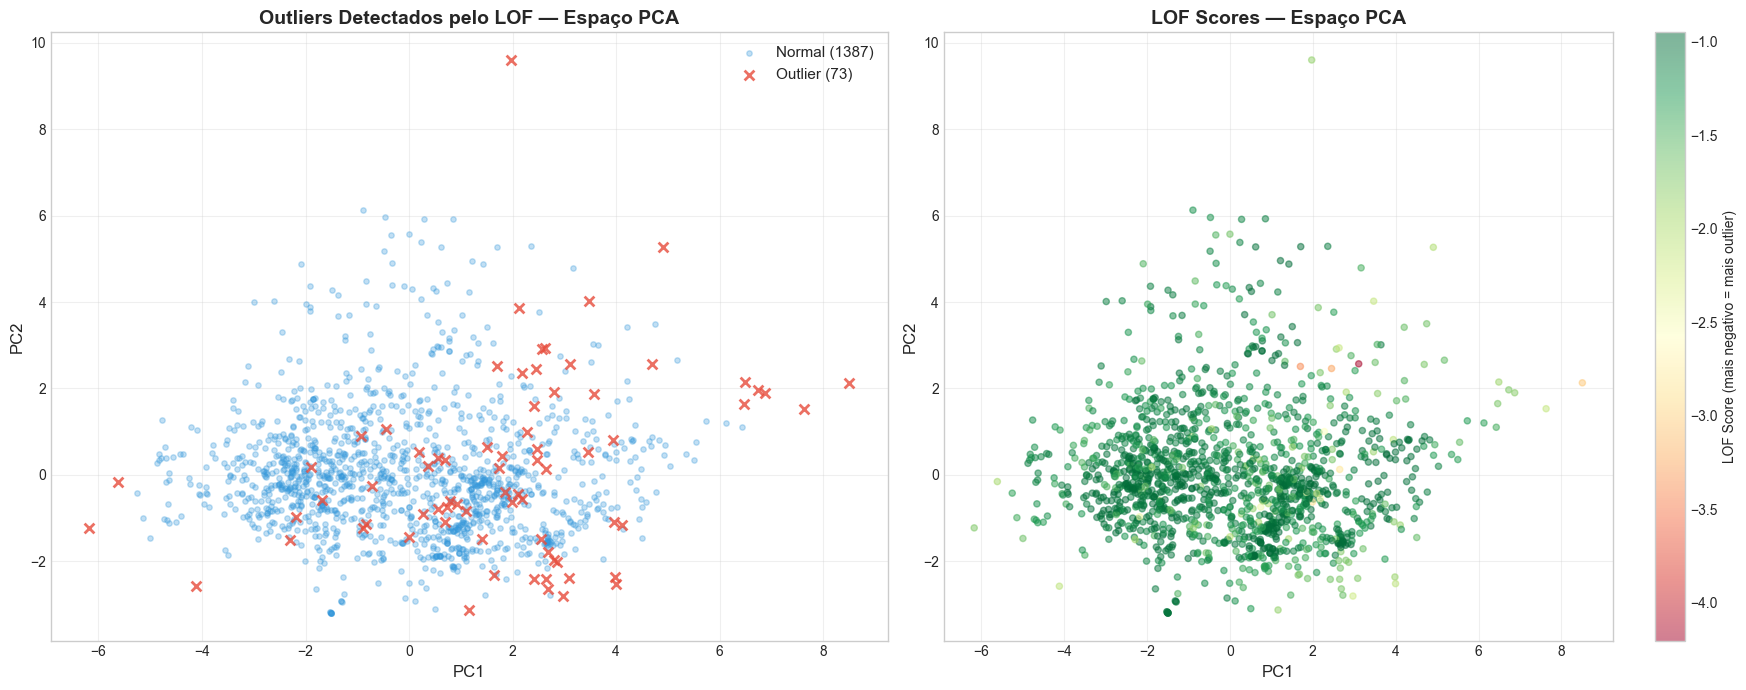

In [22]:
# Visualização dos outliers em 2D (PCA)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Outliers vs Normais
mask_normal = lof_labels == 1
mask_outlier = lof_labels == -1

axes[0].scatter(X_pca[mask_normal, 0], X_pca[mask_normal, 1],
                c='#3498db', alpha=0.3, s=15, label=f'Normal ({n_normal})')
axes[0].scatter(X_pca[mask_outlier, 0], X_pca[mask_outlier, 1],
                c='#e74c3c', alpha=0.8, s=50, marker='x',
                linewidths=2, label=f'Outlier ({n_outliers})')

axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('Outliers Detectados pelo LOF — Espaço PCA', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: LOF Scores
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=lof_scores, cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[1], label='LOF Score (mais negativo = mais outlier)')
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('LOF Scores — Espaço PCA', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 15. Análise dos Outliers Identificados
Investigar por que essas casas são consideradas atípicas comparando com o restante do dataset.

In [23]:
# Análise detalhada dos outliers
df_outlier = X.copy()
df_outlier['sale_price'] = y.values
df_outlier['lof_label'] = lof_labels
df_outlier['lof_score'] = lof_scores

outliers = df_outlier[df_outlier['lof_label'] == -1]
normais = df_outlier[df_outlier['lof_label'] == 1]

print("=" * 65)
print("  COMPARAÇÃO: OUTLIERS vs NORMAIS")
print("=" * 65)

compare_vars = ['sale_price', 'overall_qual', 'gr_liv_area', 'lot_area',
                'garage_area', 'year_built', 'totrms_abvgrd']

print(f"\n{'Variável':<18} {'Outlier (média)':>18} {'Normal (média)':>18} {'Diferença %':>15}")
print("-" * 70)

for var in compare_vars:
    mean_out = outliers[var].mean()
    mean_norm = normais[var].mean()
    diff_pct = ((mean_out - mean_norm) / mean_norm) * 100
    print(f"{var:<18} {mean_out:>18,.2f} {mean_norm:>18,.2f} {diff_pct:>14.1f}%")

  COMPARAÇÃO: OUTLIERS vs NORMAIS

Variável              Outlier (média)     Normal (média)     Diferença %
----------------------------------------------------------------------
sale_price                 266,656.74         176,408.80           51.2%
overall_qual                     6.81               6.06           12.3%
gr_liv_area                  2,079.49           1,485.78           40.0%
lot_area                    27,676.01           9,613.71          187.9%
garage_area                    651.12             463.60           40.4%
year_built                   1,977.33           1,970.95            0.3%
totrms_abvgrd                    7.52               6.47           16.3%


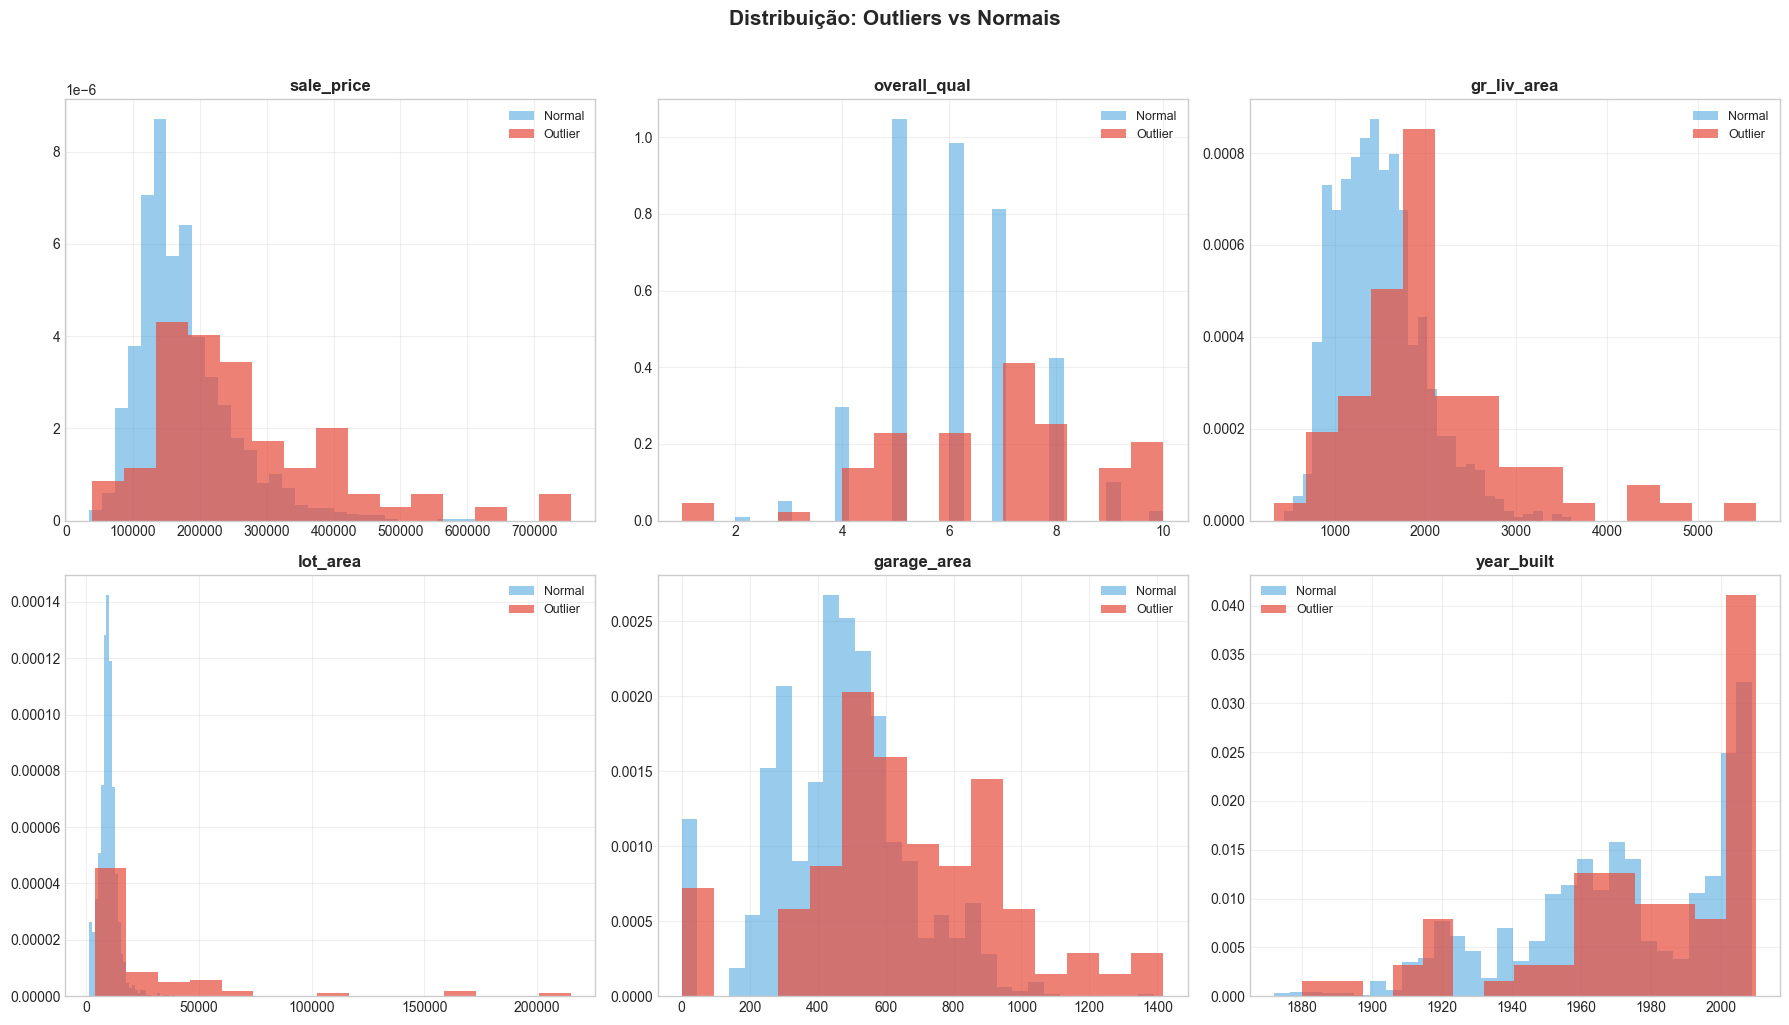

In [24]:
# Visualização comparativa Outliers vs Normais
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, var in enumerate(compare_vars[:6]):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    
    ax.hist(normais[var], bins=30, alpha=0.5, label='Normal', color='#3498db', density=True)
    ax.hist(outliers[var], bins=15, alpha=0.7, label='Outlier', color='#e74c3c', density=True)
    
    ax.set_title(var, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribuição: Outliers vs Normais', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# Top 10 outliers mais extremos
print("\nTop 10 Outliers mais extremos (menor LOF score):")
print("=" * 65)

top_outliers = outliers.sort_values('lof_score').head(10)

for i, (idx, row) in enumerate(top_outliers.iterrows(), 1):
    print(f"\n  🔴 Outlier #{i} (índice {idx}):")
    print(f"     LOF Score:   {row['lof_score']:.4f}")
    print(f"     Preço:       ${row['sale_price']:,.0f}")
    print(f"     Qualidade:   {row['overall_qual']:.0f}")
    print(f"     Área (sqft): {row['gr_liv_area']:.0f}")
    print(f"     Lote:        {row['lot_area']:.0f}")
    print(f"     Ano:         {row['year_built']:.0f}")


Top 10 Outliers mais extremos (menor LOF score):

  🔴 Outlier #1 (índice 313):
     LOF Score:   -4.2014
     Preço:       $375,000
     Qualidade:   7
     Área (sqft): 2036
     Lote:        215245
     Ano:         1965

  🔴 Outlier #2 (índice 335):
     LOF Score:   -3.4121
     Preço:       $228,950
     Qualidade:   5
     Área (sqft): 1786
     Lote:        164660
     Ano:         1965

  🔴 Outlier #3 (índice 249):
     LOF Score:   -3.2857
     Preço:       $277,000
     Qualidade:   6
     Área (sqft): 2144
     Lote:        159000
     Ano:         1958

  🔴 Outlier #4 (índice 1298):
     LOF Score:   -3.0682
     Preço:       $160,000
     Qualidade:   10
     Área (sqft): 5642
     Lote:        63887
     Ano:         2008

  🔴 Outlier #5 (índice 706):
     LOF Score:   -2.8258
     Preço:       $302,000
     Qualidade:   7
     Área (sqft): 1824
     Lote:        115149
     Ano:         1971

  🔴 Outlier #6 (índice 362):
     LOF Score:   -2.8193
     Preço:       $198,

## 16. Detecção de Outliers via API

In [26]:
# Outliers via API
api_outliers = conn.get_outliers(my_conn, n_neighbors=20)

print("Resultado da API — Outliers:")
print(f"  Tipo de resposta: {type(api_outliers)}")

if isinstance(api_outliers, dict):
    for key, value in api_outliers.items():
        if isinstance(value, list) and len(value) > 10:
            print(f"  {key}: [{value[0]}, {value[1]}, {value[2]}, ... ] ({len(value)} itens)")
        else:
            print(f"  {key}: {value}")

Resultado da API — Outliers:
  Tipo de resposta: <class 'dict'>
  usuario: joao_dev
  total_outliers: 84
  outliers: [{'id': 314, 'sale_price': 375000, 'gr_liv_area': 2036, 'overall_qual': 7, 'lof_factor': -5.720130411684986}, {'id': 336, 'sale_price': 228950, 'gr_liv_area': 1786, 'overall_qual': 5, 'lof_factor': -4.618138239477306}, {'id': 1299, 'sale_price': 160000, 'gr_liv_area': 5642, 'overall_qual': 10, 'lof_factor': -4.463926500130947}, ... ] (20 itens)


---
## 17. Resumo Final — Tarefas do João
---

In [27]:
print("=" * 65)
print("  RESUMO — CLUSTERIZAÇÃO (K-Means)")
print("=" * 65)

print(f"\n📊 Dataset: {X.shape[0]} amostras, {X.shape[1]} features numéricas")
print(f"📐 Padronização: StandardScaler (média=0, desvio=1)")
print(f"📉 Método Elbow: testados K de 2 a 10")
print(f"🎯 K ideal selecionado: {n_clusters}")
print(f"\n🏘️ Perfil dos Clusters:")

for c in range(n_clusters):
    cluster_data = df_clusters[df_clusters['cluster'] == c]
    print(f"   Cluster {c}: {len(cluster_data)} casas — Preço médio ${cluster_data['sale_price'].mean():,.0f} — Qualidade {cluster_data['overall_qual'].mean():.1f}")

print(f"\n" + "=" * 65)
print("  RESUMO — ANÁLISE DE ASSOCIAÇÃO (Apriori)")
print("=" * 65)

print(f"\n📋 Variáveis discretizadas: qualidade, area, preco, idade_casa, garagem, condicao")
print(f"📊 Itemsets frequentes encontrados: {len(frequent_itemsets)}")
print(f"📏 Regras de associação geradas: {len(rules)}")

if len(good_rules) > 0:
    print(f"✅ Regras significativas (lift>1.5, conf>60%): {len(good_rules)}")
    best_rule = good_rules.iloc[0]
    print(f"\n  🏆 Melhor regra (maior lift):")
    print(f"     SE {', '.join(list(best_rule['antecedents']))}")
    print(f"     ENTÃO {', '.join(list(best_rule['consequents']))}")
    print(f"     Lift: {best_rule['lift']:.3f}")

print(f"\n" + "=" * 65)
print("  RESUMO — DETECÇÃO DE OUTLIERS (LOF)")
print("=" * 65)

print(f"\n🔍 Algoritmo: Local Outlier Factor (n_neighbors=20, contamination=5%)")
print(f"✅ Amostras normais: {n_normal} ({n_normal/len(lof_labels)*100:.1f}%)")
print(f"🔴 Outliers detectados: {n_outliers} ({n_outliers/len(lof_labels)*100:.1f}%)")

print(f"\n📊 Características dos Outliers (comparação com normais):")
for var in ['sale_price', 'gr_liv_area', 'lot_area']:
    mean_out = outliers[var].mean()
    mean_norm = normais[var].mean()
    diff_pct = ((mean_out - mean_norm) / mean_norm) * 100
    print(f"   {var}: outliers {diff_pct:+.1f}% vs normais")

print(f"\n" + "=" * 65)
print("  Os outliers são casas que se destacam por valores extremos")
print("  em variáveis como preço, área ou qualidade, afastando-se")
print("  significativamente do padrão geral do dataset.")
print("=" * 65)

  RESUMO — CLUSTERIZAÇÃO (K-Means)

📊 Dataset: 1460 amostras, 14 features numéricas
📐 Padronização: StandardScaler (média=0, desvio=1)
📉 Método Elbow: testados K de 2 a 10
🎯 K ideal selecionado: 3

🏘️ Perfil dos Clusters:
   Cluster 0: 684 casas — Preço médio $237,080 — Qualidade 7.1
   Cluster 1: 709 casas — Preço médio $131,523 — Qualidade 5.2
   Cluster 2: 67 casas — Preço médio $130,331 — Qualidade 4.9

  RESUMO — ANÁLISE DE ASSOCIAÇÃO (Apriori)

📋 Variáveis discretizadas: qualidade, area, preco, idade_casa, garagem, condicao
📊 Itemsets frequentes encontrados: 183
📏 Regras de associação geradas: 599
✅ Regras significativas (lift>1.5, conf>60%): 214

  🏆 Melhor regra (maior lift):
     SE condicao_media, qualidade_alta, garagem_grande
     ENTÃO preco_alto, idade_casa_nova
     Lift: 3.914

  RESUMO — DETECÇÃO DE OUTLIERS (LOF)

🔍 Algoritmo: Local Outlier Factor (n_neighbors=20, contamination=5%)
✅ Amostras normais: 1387 (95.0%)
🔴 Outliers detectados: 73 (5.0%)

📊 Características do